# 01. Data Loading and Inspection

This notebook demonstrates how to load raw data from OpenMX output files, create `Snapshot` objects, and inspect their contents.

In [2]:
import torch
import matplotlib.pyplot as plt

from data.snapshot import Snapshot
from net.common import Config

## Loading a Snapshot

We can load a `Snapshot` from an OpenMX `.scfout` and `.info.out` file pair using the `Snapshot.from_openmx` class method.

In [4]:
# Load the snapshot
cfg = Config()
snapshot = Snapshot.from_openmx(
    "../../data/small/H2O/original/H2O.matrix",
    "../../data/small/H2O/original/H2O.info.out",
    cfg=cfg
)

print(snapshot)

Snapshot(
  atoms   = HHHHOO
  keys    = ['H-H', 'H-O', 'O-H', 'O-O']
  basis   = e3nn
)


The `Snapshot` object contains the Hamiltonian, Overlap, and Density matrices as `BlockMatrix` objects.

In [5]:
snapshot.density.orbital_cfg

OrbitalIrrepConfig(
  H: 3x0e+2x1o
  O: 3x0e+3x1o+2x2e
)

In [6]:
hamiltonian = snapshot.hamiltonian
overlap = snapshot.overlap
density = snapshot.density

print("Hamiltonian type:", type(hamiltonian))
print("Overlap keys:", overlap.keys())
print("Density atom counts:", density.atom_counts)

Hamiltonian type: <class 'data.block_matrix.BlockMatrix'>
Overlap keys: dict_keys(['H-H', 'H-O', 'O-O', 'O-H'])
Density atom counts: Counter({'H': 4, 'O': 2})


In [7]:
snapshot.density.atoms

('H', 'H', 'H', 'H', 'O', 'O')

In [8]:
snapshot.density["O-O"].shape

torch.Size([4, 22, 22])

In [9]:
rotated_density = snapshot.density.rotate(
    torch.tensor([
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 1]
    ])
)

## Inspecting a BlockMatrix

We can access individual blocks of a `BlockMatrix` in two ways:
1.  Using global atom indices `(i, j)`.
2.  Using a pair-key string `"A-B"`.

In [10]:
# Accessing a block using global indices (e.g., from atom 0 to atom 4)
block_0_4 = density[(0, 4)]
print("Shape of density block (0, 4):", block_0_4.shape)

# Accessing all blocks for a pair-key (e.g., "O-O")
blocks_O_O = density["O-O"]
print("Shape of all 'O-O' density blocks:", blocks_O_O.shape)

Shape of density block (0, 4): torch.Size([9, 22])
Shape of all 'O-O' density blocks: torch.Size([4, 22, 22])


### Diagonal and Off-Diagonal Blocks

The `diag()` and `offdiag()` methods provide easy access to the diagonal and off-diagonal blocks of a `BlockMatrix`.

In [11]:
diag_blocks = density.diag()
offdiag_blocks = density.offdiag()

print("Diagonal keys:", diag_blocks.keys())
print("Off-diagonal keys:", offdiag_blocks.keys())

Diagonal keys: dict_keys(['H-H', 'O-O'])
Off-diagonal keys: dict_keys(['H-H', 'H-O', 'O-O', 'O-H'])


### Dense Representation

For visualization and debugging, we can convert a `BlockMatrix` to a dense `torch.Tensor`.

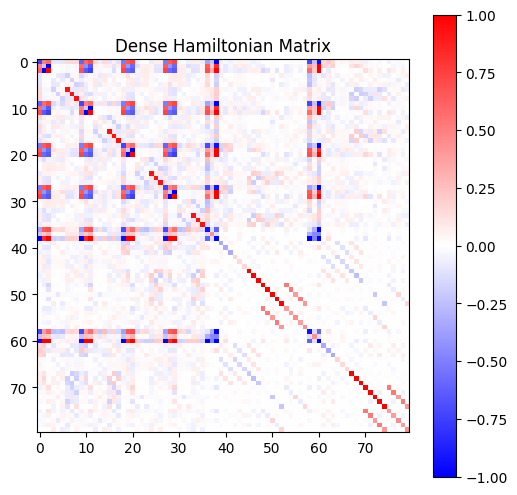

In [21]:
dense_hamiltonian = hamiltonian.to_dense()

plt.figure(figsize=(6, 6))
plt.imshow(dense_hamiltonian, cmap="bwr", vmin=-1, vmax=1)
plt.title("Dense Hamiltonian Matrix")
plt.colorbar()
plt.show()

In [11]:
dense_hamiltonian.shape

torch.Size([80, 80])

## Physics Observables

The `Snapshot` class provides methods to compute physical observables like the total energy and the number of electrons or electronic density of states.

In [12]:
snapshot = Snapshot.from_openmx(
    "../../data/big/silicon/900K/Si_DM",
    "../../data/big/silicon/900K/info.txt"
)

energy = snapshot.get_energy()
num_electrons = snapshot.get_number_of_electrons()

print(f"Total energy: {energy.item():.4f} eV")
print(f"Number of electrons: {num_electrons.item():.4f}")

Total energy: -262.2086 eV
Number of electrons: 863.9997


### Calculating the Density of States (DOS)

You can calculate the density of states from a `Snapshot` object using a class method. Method returns:
- `grid` *(torch.Tensor)* – Energy grid.
- `dos` *(torch.Tensor)* – Corresponding DOS values.

`snapshot.dos(sigma, bin_width, E_min, E_max)` Parameters:

| Parameter   | Type   | Unit | Description |
|-------------|--------|------|-------------|
| `sigma`     | float  | eV   | Gaussian broadening width. |
| `bin_width` | float  | eV   | Energy bin size. |
| `E_min`     | float  | eV   | Minimum energy value for DOS calculation. |
| `E_max`     | float  | eV   | Maximum energy value for DOS calculation. |




Text(0, 0.5, 'DOS (states/eV)')

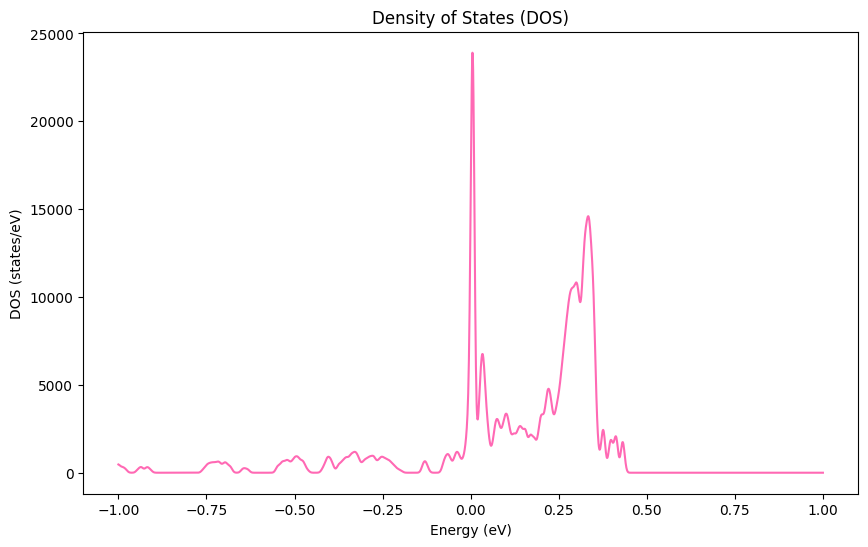

In [13]:
sigma = 0.005
bin_width = 0.001
E_min = -1
E_max = 1


energy_grid, dos_values = snapshot.dos(sigma, bin_width, E_min, E_max)

# Plotting the Density of States (DOS)
plt.figure(figsize=(10, 6))
plt.plot(energy_grid, dos_values, color="hotpink")
plt.title("Density of States (DOS)")
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states/eV)")

## Filtering by Distance

We can filter the snapshot to include only edges within a certain cutoff radius. This is useful for creating graphs with different levels of connectivity.

In [14]:
print("Number of electrons before filtering:", snapshot.get_number_of_electrons().item())

# Filter the snapshot to include only edges up to 5.0 Å
filtered_snapshot = snapshot.filter_by_distance(5.0)

print("Number of electrons after filtering:", filtered_snapshot.get_number_of_electrons().item())

Number of electrons before filtering: 863.9996948242188
Number of electrons after filtering: 859.9149780273438
